In [2]:
import logging
import pandas as pd
import pyXLMS
from pyXLMS_adaptor import read
from mokapot_rescore import rescore
from post_process import group_by_residue_pair  # noqa: F401

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

In [3]:
from IPython.core.magic import register_cell_magic


@register_cell_magic
def skip(line, cell):
    return

In [4]:
%%skip

df = pd.read_csv(
    "../data/THIDDIAXL003_Cas9_PhoX_DIA12_CeleEntrap_100per_LibSizeTest_SN20c4_Report_FM_crosslinking_plusDecoy (Normal).tsv_annotated.csv.xz",
    compression="xz",
    low_memory=False,
)

In [5]:
%%skip

df = group_by_residue_pair(df)
df.to_csv("../data/entrapment_grouped.csv", index=False)

In [6]:
df = pd.read_csv("../data/entrapment_grouped.csv", low_memory=False)

In [7]:
print(f"Number of CSMs with missing organism label: {sum(df['PG.Organisms'].isna())}")

Number of CSMs with missing organism label: 1


In [8]:
df["PG.Organisms"].value_counts()

PG.Organisms
S pyogenes    14492
Celegans       3395
Name: count, dtype: int64

In [9]:
spyo = df[df["PG.Organisms"] == "S pyogenes"]
cele = df[df["PG.Organisms"] == "Celegans"]

In [35]:
csms = read(df, "EG.Cscore")["crosslink-spectrum-matches"]
spyo_csms = read(spyo, "EG.Cscore")["crosslink-spectrum-matches"]
cele_csms = read(cele, "EG.Cscore")["crosslink-spectrum-matches"]

Reading CSMs...: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 3395/3395 [00:00<00:00, 5493.51it/s]


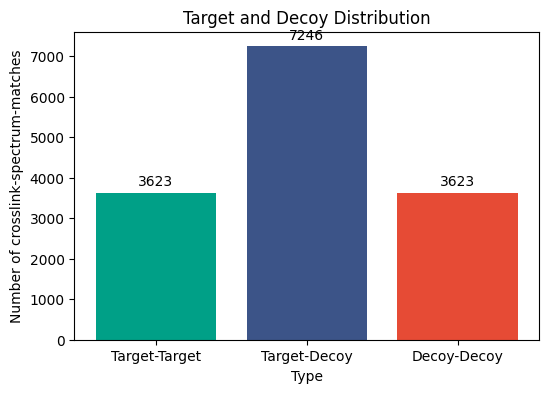

In [11]:
pyXLMS.plotting.plot_target_decoy_distribution(spyo_csms, figsize=(6, 4));

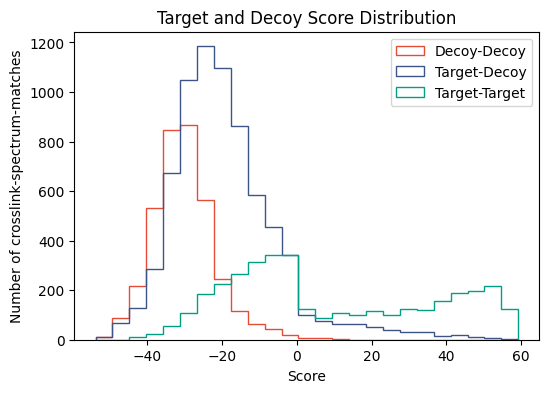

In [12]:
pyXLMS.plotting.plot_score_distribution(spyo_csms, figsize=(6, 4));

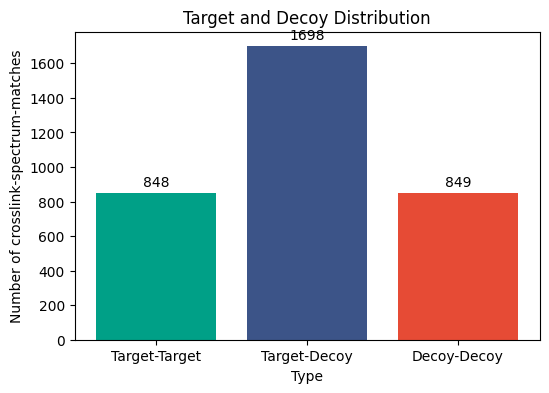

In [13]:
pyXLMS.plotting.plot_target_decoy_distribution(cele_csms, figsize=(6, 4));

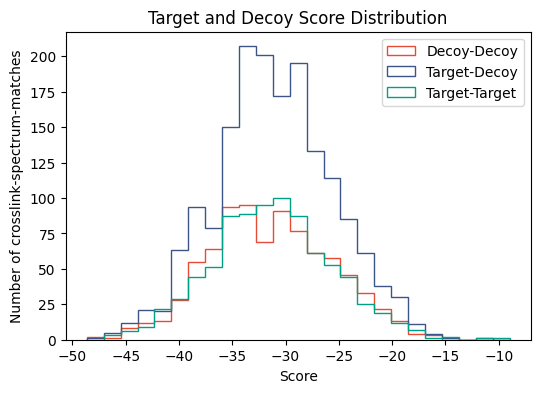

In [14]:
pyXLMS.plotting.plot_score_distribution(cele_csms, figsize=(6, 4));

In [15]:
rescored_level_csm = rescore(df, level="CSM")

INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 17888 PSMs:
	- Target PSMs: 4472
	- Decoy PSMs: 13416
	- Unique spectra: 17888
	- Unique peptides: 13889
	- Features: ('EG.Cscore', 'FG.Charge', 'PG.Pvalue', 'PG.PValue (Run-Wise)', 'PG.Qvalue', 'PG.QValue (Run-Wise)', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFul

In [16]:
rescored_level_csm_csms = read(rescored_level_csm, score="Mokapot Score")[
    "crosslink-spectrum-matches"
]

Reading CSMs...: 100%|███████████████████████████████████████████████████████████████████████████████████████| 17888/17888 [00:03<00:00, 5504.02it/s]


In [17]:
rescored_level_psm = rescore(df, level="PSM")

INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 17888 PSMs:
	- Target PSMs: 8944
	- Decoy PSMs: 8944
	- Unique spectra: 17888
	- Unique peptides: 1239
	- Features: ('EG.Cscore', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.RelativeMatchScoreA', 'PP.PartialCscoreA', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageAlpha', 'PP.UniScoreAlpha', 'PP.PepLen

In [18]:
rescored_level_psm_csms = read(rescored_level_psm, score="Mokapot Score")[
    "crosslink-spectrum-matches"
]

Reading CSMs...: 100%|███████████████████████████████████████████████████████████████████████████████████████| 17888/17888 [00:03<00:00, 5379.45it/s]


In [19]:
def pipeline(csms, fdr: float = 0.01):
    u = pyXLMS.transform.unique(csms)
    v = pyXLMS.transform.validate(u, fdr)
    t = pyXLMS.transform.targets_only(v)
    return t

In [20]:
def get_experimental_fdr(
    csms, true_label="S pyogenes", label_col="PG.Organisms"
) -> float:
    nr_true = 0
    nr_false = 0
    for csm in csms:
        label = csm["additional_information"]["source"][label_col]
        if label is not None and true_label in label:
            nr_true += 1
        else:
            nr_false += 1
    return (nr_false / nr_true) * 100.0

In [21]:
rescored_target_csm = pipeline(rescored_level_csm_csms)

Iterating over scores for FDR calculation...:  75%|██████████████████████████████████████████▊              | 13416/17888 [00:00<00:00, 79767.49it/s]


In [22]:
print(
    f"[CSM-level Rescoring] Number of hits at 1% FDR: {len(rescored_target_csm)}; Experimental FDR: {get_experimental_fdr(rescored_target_csm)}%;"
)

[CSM-level Rescoring] Number of hits at 1% FDR: 4472; Experimental FDR: 23.433618548164503%;


In [23]:
rescored_target_psm = pipeline(rescored_level_psm_csms)

Iterating over scores for FDR calculation...:  94%|████████████████████████████████████████████████████▋   | 16843/17888 [00:00<00:00, 128839.79it/s]


In [24]:
print(
    f"[PSM-level Rescoring] Number of hits at 1% FDR: {len(rescored_target_psm)}; Experimental FDR: {get_experimental_fdr(rescored_target_psm)}%;"
)

[PSM-level Rescoring] Number of hits at 1% FDR: 1035; Experimental FDR: 0.0%;


In [36]:
non_rescored_target = pipeline(csms)

Iterating over scores for FDR calculation...:  98%|██████████████████████████████████████████████████████▉ | 17560/17888 [00:00<00:00, 128324.28it/s]


In [37]:
print(
    f"[No Rescoring] Number of hits at 1% FDR: {len(non_rescored_target)}; Experimental FDR: {get_experimental_fdr(non_rescored_target)}%;"
)

[No Rescoring] Number of hits at 1% FDR: 325; Experimental FDR: 0.0%;


In [25]:
rescored_level_csm_csms_spyo = list()
rescored_level_csm_csms_cele = list()
for csm in rescored_level_csm_csms:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        rescored_level_csm_csms_spyo.append(csm)
    elif label is not None and "Celegans" in label:
        rescored_level_csm_csms_cele.append(csm)

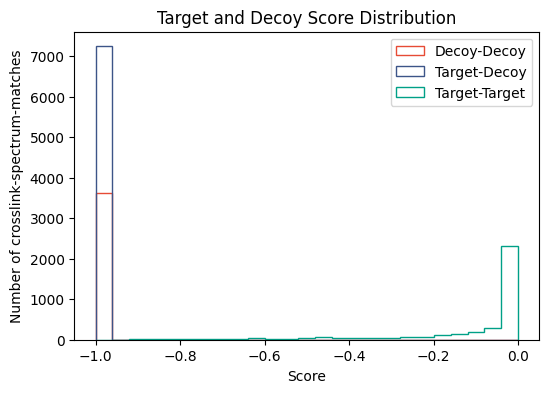

In [26]:
pyXLMS.plotting.plot_score_distribution(rescored_level_csm_csms_spyo, figsize=(6, 4));

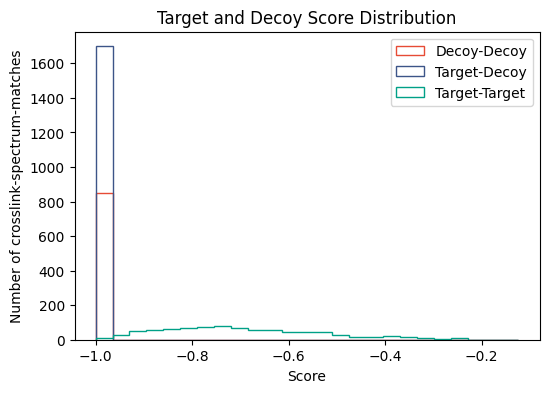

In [27]:
pyXLMS.plotting.plot_score_distribution(rescored_level_csm_csms_cele, figsize=(6, 4));

In [28]:
rescored_level_psm_csms_spyo = list()
rescored_level_psm_csms_cele = list()
for csm in rescored_level_psm_csms:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        rescored_level_psm_csms_spyo.append(csm)
    elif label is not None and "Celegans" in label:
        rescored_level_psm_csms_cele.append(csm)

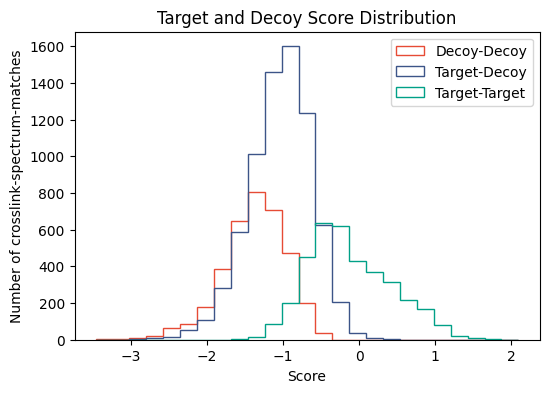

In [29]:
pyXLMS.plotting.plot_score_distribution(rescored_level_psm_csms_spyo, figsize=(6, 4));

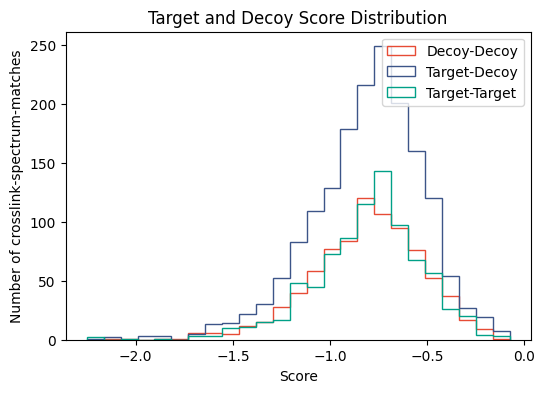

In [30]:
pyXLMS.plotting.plot_score_distribution(rescored_level_psm_csms_cele, figsize=(6, 4));

In [31]:
rescored_level_csm_csms_t = pyXLMS.transform.targets_only(rescored_level_csm_csms)
for csm in rescored_level_csm_csms_t:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        csm["alpha_decoy"] = False
        csm["beta_decoy"] = False
    elif label is not None and "Celegans" in label:
        csm["alpha_decoy"] = True
        csm["beta_decoy"] = True

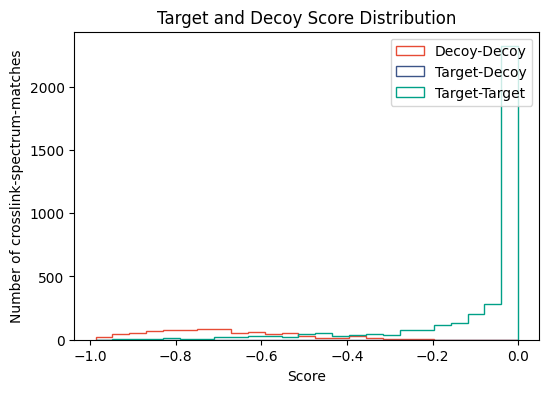

In [32]:
pyXLMS.plotting.plot_score_distribution(rescored_level_csm_csms_t, figsize=(6, 4));

In [33]:
rescored_level_psm_csms_t = pyXLMS.transform.targets_only(rescored_level_psm_csms)
for csm in rescored_level_psm_csms_t:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        csm["alpha_decoy"] = False
        csm["beta_decoy"] = False
    elif label is not None and "Celegans" in label:
        csm["alpha_decoy"] = True
        csm["beta_decoy"] = True

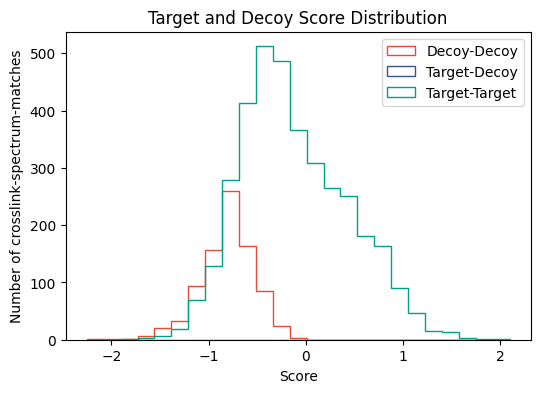

In [34]:
pyXLMS.plotting.plot_score_distribution(rescored_level_psm_csms_t, figsize=(6, 4));